In [1]:
library(clusterProfiler)
library("enrichplot")



clusterProfiler v4.6.2  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter




In [2]:
foldchanges <- readRDS("foldchanges.rds") 

In [3]:
## Sort fold changes in decreasing order
foldchanges <- sort(foldchanges, decreasing = TRUE)

In [4]:
kegg_organism = "hsa"
kk2 = gseKEGG(geneList     = foldchanges,
               organism     = kegg_organism,
               minGSSize    = 3,
               maxGSSize    = 800,
               pvalueCutoff = 0.05,
               pAdjustMethod = "none",
               keyType       = "ncbi-geneid")

Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...

Reading KEGG annotation online: "https://rest.kegg.jp/conv/ncbi-geneid/hsa"...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



In [5]:
selected_pathways <- c("DNA replication","Fanconi anemia pathway","Mismatch repair", "Cell cycle",#neg
                       "Rheumatoid arthritis","NF-kappa B signaling pathway","JAK-STAT signaling pathway",
                      "Cytokine-cytokine receptor interaction","NOD-like receptor signaling pathway","Transcriptional misregulation in cancer",
                      "Base excision repair","Fc gamma R-mediated phagocytosis","MicroRNAs in cancer","Lysosome",
                       "TGF-beta signaling pathway", "ECM-receptor interaction","Platinum drug resistance") #pos

Warning message in emapplot.enrichResult(x, showCategory = showCategory, ...):
“Use 'cluster.params = list(cluster = your_value)' instead of 'group_category'.
 The group_category parameter will be removed in the next version.”
Warning message in emapplot.enrichResult(x, showCategory = showCategory, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
Warning message in emapplot.enrichResult(x, showCategory = showCategory, ...):
“Use 'cluster.params = list(legend = your_value)' instead of 'group_legend'.
 The group_legend parameter will be removed in the next version.”


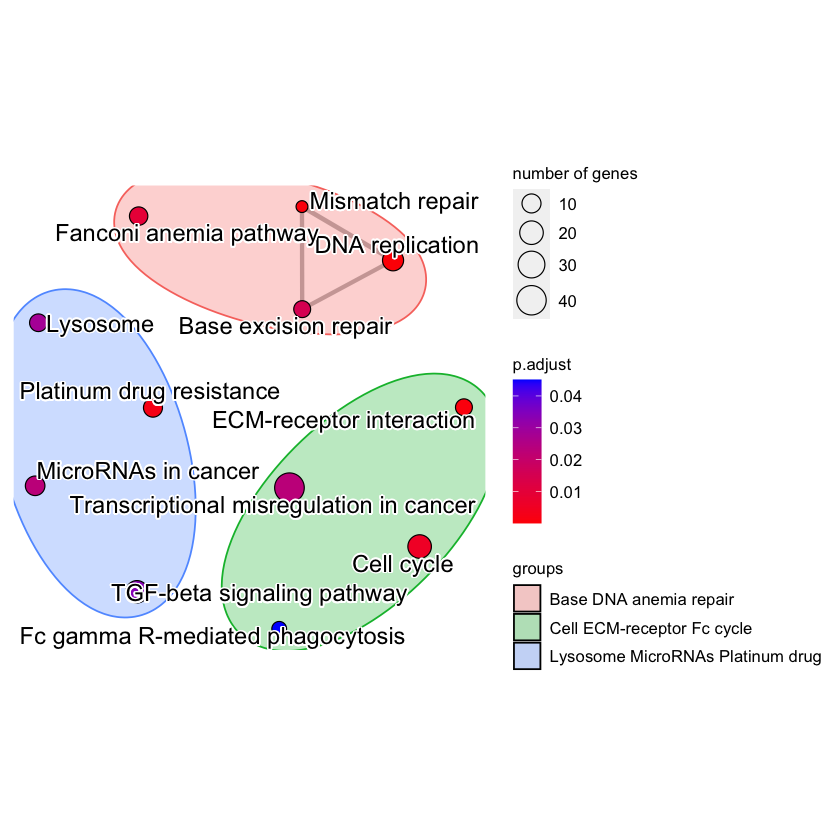

In [6]:
#set.seed(123)
x2 = pairwise_termsim(kk2)
xc <- emapplot(x2, showCategory = selected_pathways,group_category = T,group_legend = T,nCluster = 3, layaout= 'gem')
xc